# Critical Earth — Preliminary Data Analysis
**DTU 02806 Social Data Analysis & Visualization**

Research question: *Is the global critical minerals supply chain splitting into two blocs?*

This notebook covers:
1. Dataset inventory — size, shape, variables
2. Data properties — date ranges, geo coverage, key fields
3. Fundamental distributions — histograms, value counts, maps

In [2]:
import os
os.environ.pop('MPLBACKEND', None)

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.titlecolor'] = 'white'

RAW  = Path('../../data/raw')
PROC = Path('../../data/processed')

MINERALS_8 = ['Cobalt', 'Copper', 'Gallium', 'Graphite', 'Lithium',
              'Platinum', 'Rare earths', 'Neodymium']
OWID_8 = ['Cobalt', 'Copper', 'Gallium', 'Graphite', 'Lithium',
          'Platinum group metals (platinum)', 'Rare earths']

COLORS = {
    'China': '#DE2910', 'United States': '#3C3B6E', 'EU': '#003399',
    'Australia': '#FFD700', 'DRC': '#007FFF', 'South Africa': '#007A4D',
    'Other': '#888888'
}
print('Imports OK')

Imports OK


---
## 1. Dataset Inventory
**Bullet summary for presentation:**
- **A** USGS Critical Minerals pts shapefile — 2,121 deposit locations, 8 variables, geo
- **B** USGS REE Occurrences Excel — 3,114 REE deposits, 62 variables, global
- **C** OWID Mine Production CSV — 4,659 rows, 3 variables, 54 minerals, 1900–2024
- **D** USGS Historical Prices (7 XLS) — ~86–130 rows each, annual unit values per mineral
- **D+** USGS MCS 2025 CSVs — production (99 rows), prices (23 rows), end-uses (37 rows)
- **E** Mining vs Processing CSVs — 140 country×mineral rows, China summary (9 minerals)
- **G** Natural Earth — 177 country polygons for base maps

In [3]:
# Load all datasets
gdf_pts   = gpd.read_file(RAW / 'A USGS Critical Minerals GDB' / 'PP1802_CritMin_pts.shp')
df_ree    = pd.read_excel(RAW / 'B USGS REE Occurrences GDB' / 'Global_REE_occurrence_database.xlsx')
df_owid   = pd.read_csv(RAW / 'C OWID Mine Production' / 'global-mine-production-minerals.csv')
df_eu     = pd.read_csv(RAW / 'D+ USGS MCS 2025' / 'mcs2025_all_end_uses.csv', comment='#')
df_prices = pd.read_csv(RAW / 'D+ USGS MCS 2025' / 'mcs2025_all_prices.csv', comment='#')
df_mvp    = pd.read_csv(RAW / 'E USGS Fact Sheet Mining vs Processing' / 'mining_vs_processing_extracted.csv', comment='#')
df_china  = pd.read_csv(RAW / 'E USGS Fact Sheet Mining vs Processing' / 'china_mining_vs_processing_summary.csv', comment='#')
gdf_world = gpd.read_file(RAW / 'G Natural Earth' / 'ne_110m_admin_0_sovereignty.shp')

inventory = [
    ('A  Deposit locations (pts)',  gdf_pts.shape,   '~0.3 MB',  'Shapefile, geo'),
    ('B  REE occurrences',          df_ree.shape,    '1.1 MB',   'Excel, global'),
    ('C  OWID mine production',     df_owid.shape,   '0.1 MB',   'CSV, 1900-2024'),
    ('D+ MCS end-uses',             df_eu.shape,     '<0.1 MB',  'CSV, 2024'),
    ('D+ MCS prices',               df_prices.shape, '<0.1 MB',  'CSV, 2020-2024'),
    ('E  Mining vs processing',     df_mvp.shape,    '<0.1 MB',  'CSV, 2023'),
    ('G  Natural Earth countries',  gdf_world.shape, '~0.5 MB',  'Shapefile, geo'),
]

print(f"{'Dataset':<35} {'Rows':>6} {'Cols':>6}  Notes")
print('-' * 70)
for name, shape, size, notes in inventory:
    print(f"{name:<35} {shape[0]:>6} {shape[1]:>6}  {size}  {notes}")

ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

---
## 2. Dataset Properties

In [ ]:
# A — deposit fields and mineral breakdown
print('=== A: USGS Critical Minerals Deposits ===')
print(f'Columns: {list(gdf_pts.columns)}')
print(f'CRS: {gdf_pts.crs}')
print(f'\nTop minerals by deposit count:')
print(gdf_pts['CRITICAL_M'].value_counts().head(15).to_string())

=== A: USGS Critical Minerals Deposits ===
Columns: ['DEPOSIT_NA', 'CRITICAL_M', 'DEPOSIT_TY', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'LOC_DETAIL', 'geometry']
CRS: EPSG:4326

Top minerals by deposit count:
CRITICAL_M
Gallium                    429
Beryllium                  280
Cobalt                     196
Platinum-Group Elements    141
Graphite                   110
Tin                        106
Fluorite                    98
Rhenium                     98
Titanium                    96
Lithium                     93
Vanadium                    74
Tellurium                   60
Rare-Earth Elements         41
Niobium and Tantalum        36
Manganese                   35


In [ ]:
# B — REE fields
print('=== B: REE Occurrences ===')
print(f'Columns (first 15): {list(df_ree.columns[:15])}')
print(f'\nCountries with most REE deposits:')
print(df_ree['Country'].value_counts().head(10).to_string())
print(f'\nHas lat/lon? {"Latitude" in df_ree.columns or "Lat" in df_ree.columns}')
# find coordinate columns
coord_cols = [c for c in df_ree.columns if any(x in c.lower() for x in ['lat','lon','x','y','coord'])]
print(f'Coordinate-like columns: {coord_cols}')

=== B: REE Occurrences ===
Columns (first 15): ['OBJECTID', 'ID_No', 'Name', 'Name_Other', 'Components', 'Part_of', 'Rec_Type', 'Rec_Note', 'Country', 'State_Prov', 'Latitude', 'Longitude', 'Loc_Note', 'Dep_Type', 'Dep_Note']

Countries with most REE deposits:
Country
Australia             466
Canada                254
China                 214
Brazil                173
Kazakhstan            161
United States         153
Russian Federation    148
India                 105
Sweden                 88
Mongolia               81

Has lat/lon? True
Coordinate-like columns: ['Rec_Type', 'Country', 'Latitude', 'Longitude', 'Dep_Type', 'Company', 'Discov_Yr', 'Expl_Note', 'P_Years', 'RR_Yr_Est']


In [ ]:
# C — OWID date range and coverage
print('=== C: OWID Mine Production ===')
print(f'Year range: {df_owid["Year"].min()} – {df_owid["Year"].max()}')
print(f'Total minerals covered: {df_owid["Entity"].nunique()}')
print(f'\nOur 8 minerals present: ', end='')
present = [m for m in OWID_8 if m in df_owid['Entity'].values]
print(present)
df_owid.rename(columns={'Global mine production of different minerals': 'production'}, inplace=True)

=== C: OWID Mine Production ===
Year range: 1900 – 2024
Total minerals covered: 54

Our 8 minerals present: ['Cobalt', 'Copper', 'Graphite', 'Lithium', 'Platinum group metals (platinum)', 'Rare earths']


In [ ]:
# D — USGS Historical price XLS structure (cobalt as example)
print('=== D: USGS Historical Prices (cobalt example) ===')
df_co = pd.read_excel(RAW / 'D USGS Historical Prices' / 'ds140-cobalt-2021.xlsx')
print(f'Shape: {df_co.shape}')
print(f'Columns: {list(df_co.columns)}')
print(df_co.head(3))

=== D: USGS Historical Prices (cobalt example) ===
Shape: (129, 14)
Columns: ['COBALT STATISTICS1', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']
                                  COBALT STATISTICS1 Unnamed: 1 Unnamed: 2  \
0                             U.S. GEOLOGICAL SURVEY        NaN        NaN   
1  [All values are in metric tons (t) cobalt cont...        NaN        NaN   
2                  Last modification: April 30, 2024        NaN        NaN   

  Unnamed: 3 Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0        NaN        NaN        NaN        NaN        NaN        NaN   
1        NaN        NaN        NaN        NaN        NaN        NaN   
2        NaN        NaN        NaN        NaN        NaN        NaN   

  Unnamed: 9 Unnamed: 10 Unnamed: 11 Unnamed: 12 Unnamed: 13  
0        NaN         NaN         NaN         NaN     

---
## 3. Fundamental Distributions
### 3a. Global Deposit Map (Dataset A)

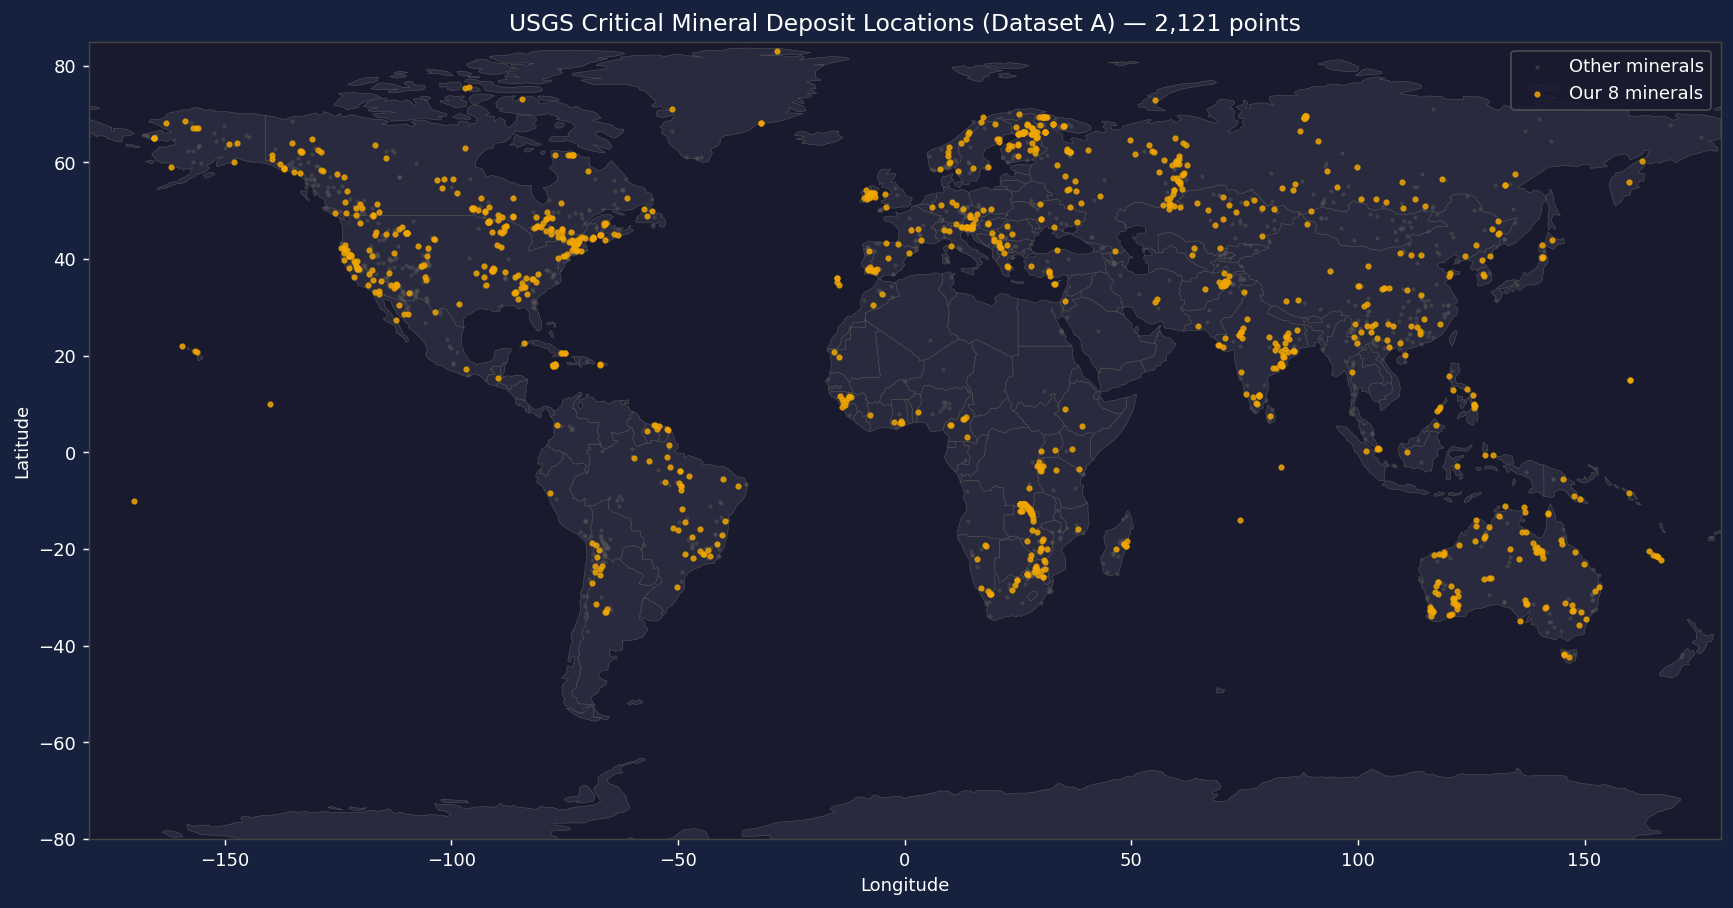

Highlighted deposits (our 8 minerals): 1032 / 2121


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
gdf_world.plot(ax=ax, color='#2a2a3e', edgecolor='#555', linewidth=0.3)

# highlight our 8 minerals
target_kw = ['cobalt','copper','gallium','graphite','lithium','platinum','rare earth','neodymium']
mask_8 = gdf_pts['CRITICAL_M'].str.lower().apply(
    lambda x: any(k in str(x) for k in target_kw)
)
gdf_other = gdf_pts[~mask_8]
gdf_8     = gdf_pts[mask_8]

gdf_other.plot(ax=ax, color='#555', markersize=2, alpha=0.4, label='Other minerals')
gdf_8.plot(ax=ax, color='#f0a500', markersize=6, alpha=0.8, label='Our 8 minerals')

ax.set_title('USGS Critical Mineral Deposit Locations (Dataset A) — 2,121 points', fontsize=13)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(facecolor='#1a1a2e', edgecolor='#555')
ax.set_xlim(-180, 180); ax.set_ylim(-80, 85)
plt.tight_layout()
plt.show()
print(f'Highlighted deposits (our 8 minerals): {mask_8.sum()} / {len(gdf_pts)}')

### 3b. Deposit Count by Mineral — Top 20 (Dataset A)

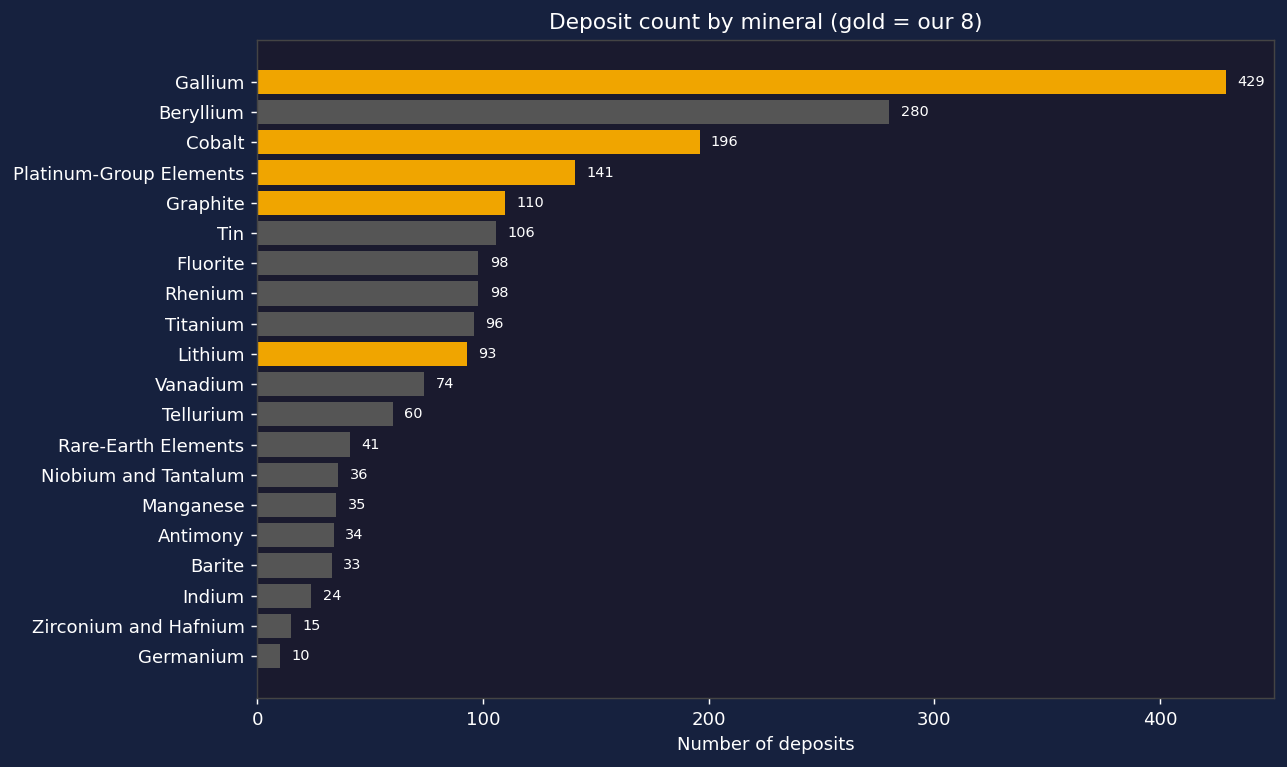

In [ ]:
top20 = gdf_pts['CRITICAL_M'].value_counts().head(20)
colors_bar = ['#f0a500' if any(k in str(v).lower() for k in target_kw) else '#555'
              for v in top20.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1])
ax.set_xlabel('Number of deposits')
ax.set_title('Deposit count by mineral (gold = our 8)', fontsize=12)
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 3c. REE Deposits by Country — Top 15 (Dataset B)

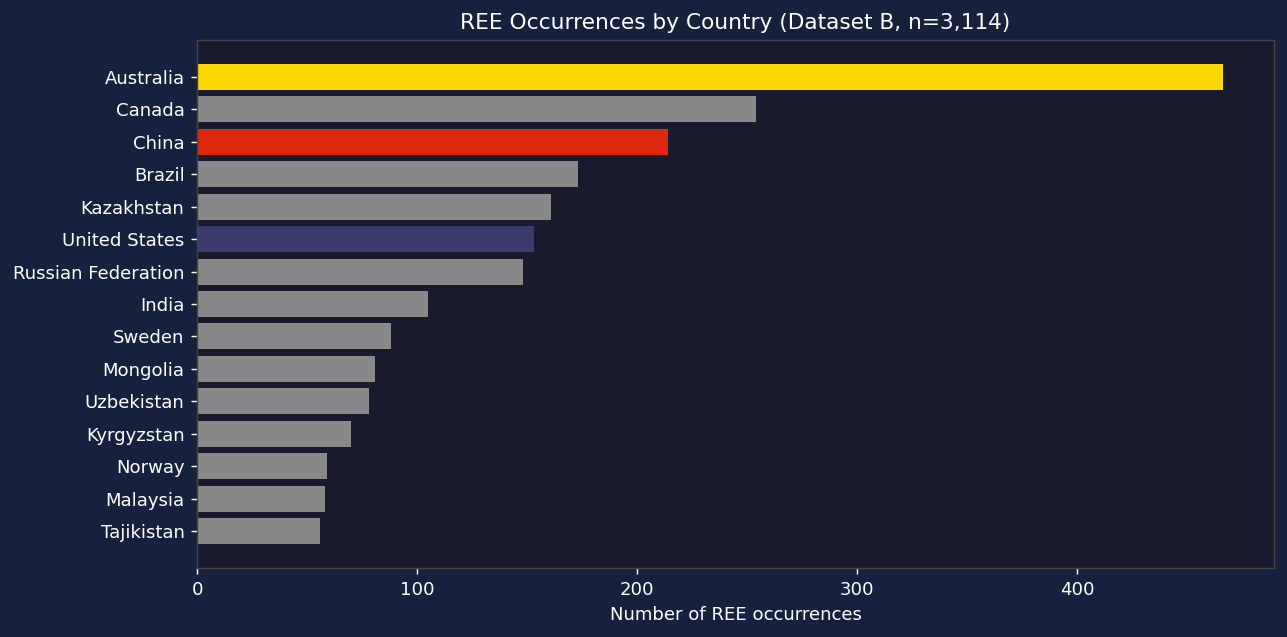

In [ ]:
top_ree = df_ree['Country'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [COLORS.get(c, '#888888') for c in top_ree.index]
ax.barh(top_ree.index[::-1], top_ree.values[::-1], color=bar_colors[::-1])
ax.set_xlabel('Number of REE occurrences')
ax.set_title(f'REE Occurrences by Country (Dataset B, n={len(df_ree):,})', fontsize=12)
plt.tight_layout()
plt.show()

### 3d. Global Mine Production Over Time — Our 8 Minerals (Dataset C)

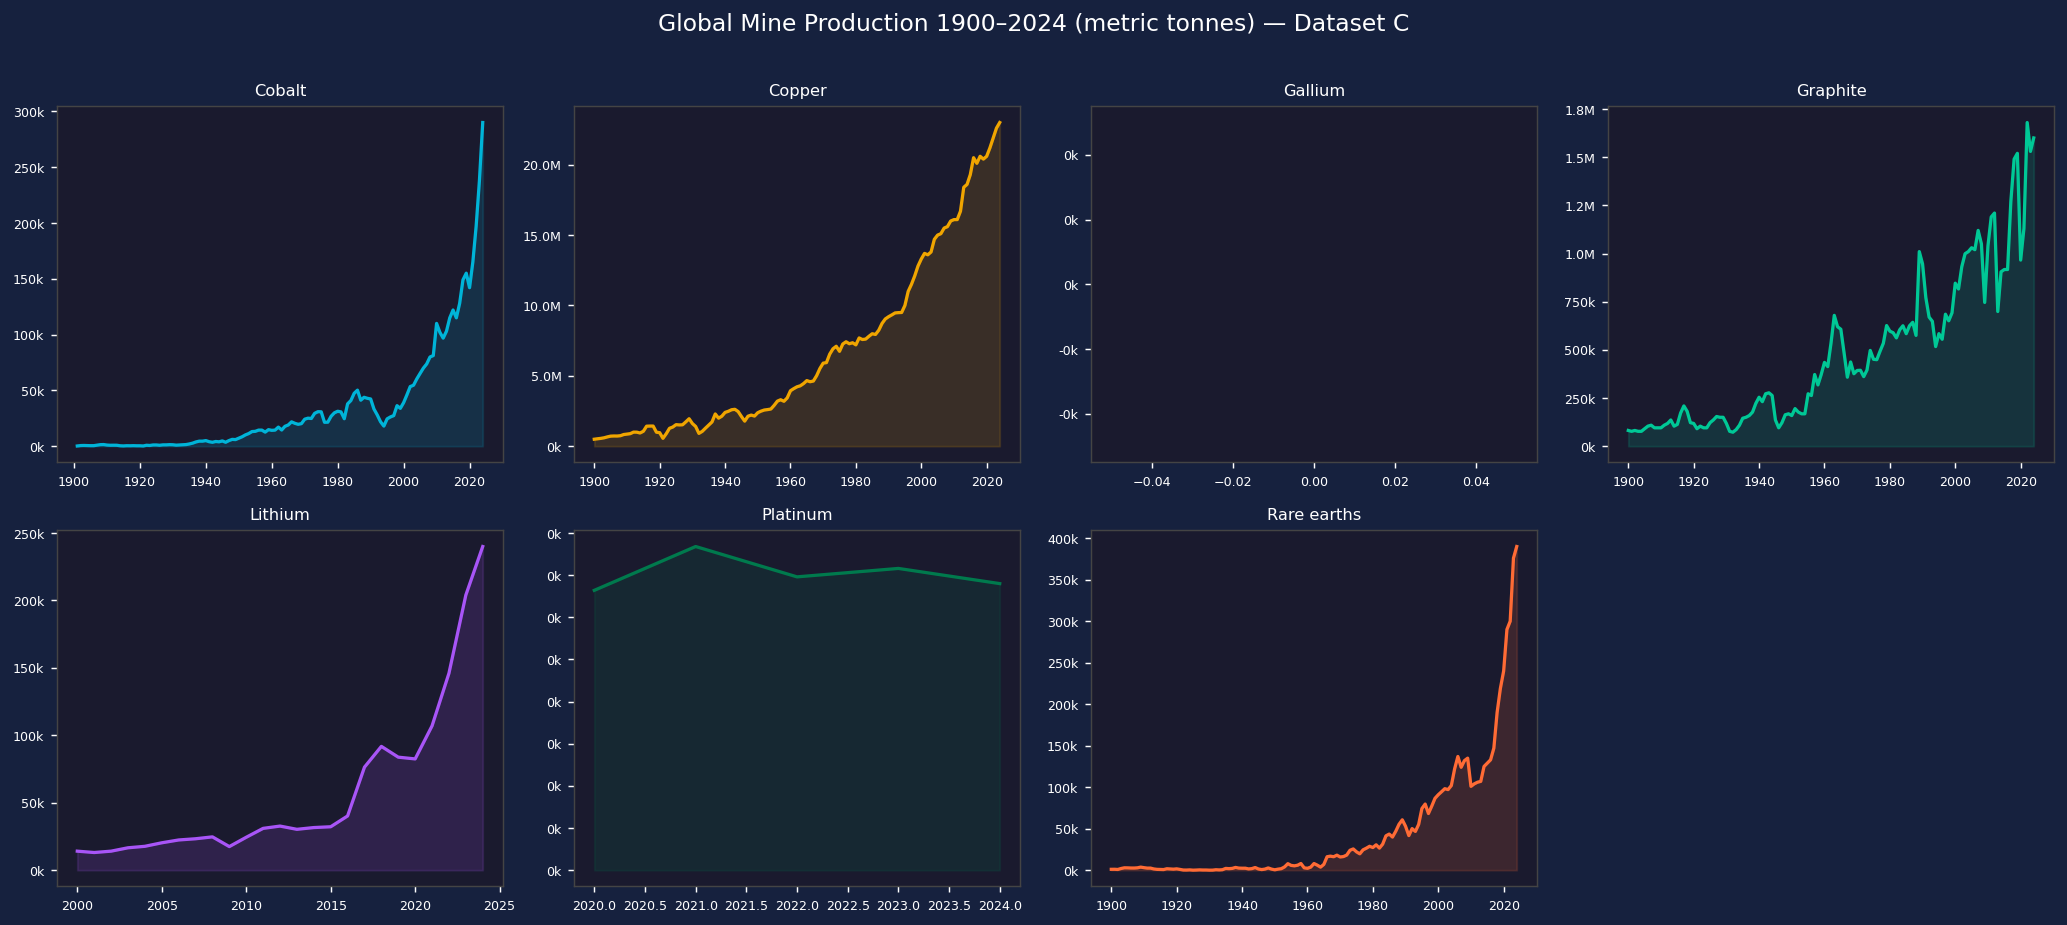

Year range per mineral:
  Cobalt                                        1901–2024  (124 rows)
  Copper                                        1900–2024  (125 rows)
  Gallium                                       nan–nan  (0 rows)
  Graphite                                      1900–2024  (125 rows)
  Lithium                                       2000–2024  (25 rows)
  Platinum group metals (platinum)              2020–2024  (5 rows)
  Rare earths                                   1900–2024  (125 rows)


In [ ]:
df_8 = df_owid[df_owid['Entity'].isin(OWID_8)].copy()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.flatten()

palette = ['#00b4d8','#f0a500','#DE2910','#00c896','#a855f7','#007A4D','#ff6b35']

for i, mineral in enumerate(OWID_8):
    df_m = df_8[df_8['Entity'] == mineral].sort_values('Year')
    axes[i].plot(df_m['Year'], df_m['production'], color=palette[i], linewidth=1.8)
    axes[i].fill_between(df_m['Year'], df_m['production'], alpha=0.15, color=palette[i])
    axes[i].set_title(mineral.replace('Platinum group metals (platinum)', 'Platinum'), fontsize=9)
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
    axes[i].tick_params(labelsize=7)

if len(OWID_8) < 8:
    axes[-1].set_visible(False)

fig.suptitle('Global Mine Production 1900–2024 (metric tonnes) — Dataset C', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Year range per mineral:')
for mineral in OWID_8:
    df_m = df_8[df_8['Entity'] == mineral]
    print(f'  {mineral:<45} {df_m["Year"].min()}–{df_m["Year"].max()}  ({len(df_m)} rows)')

### 3e. End-Use Distribution per Mineral (Dataset D+)

C:\Users\aholm\AppData\Local\Temp\ipykernel_24528\988578116.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


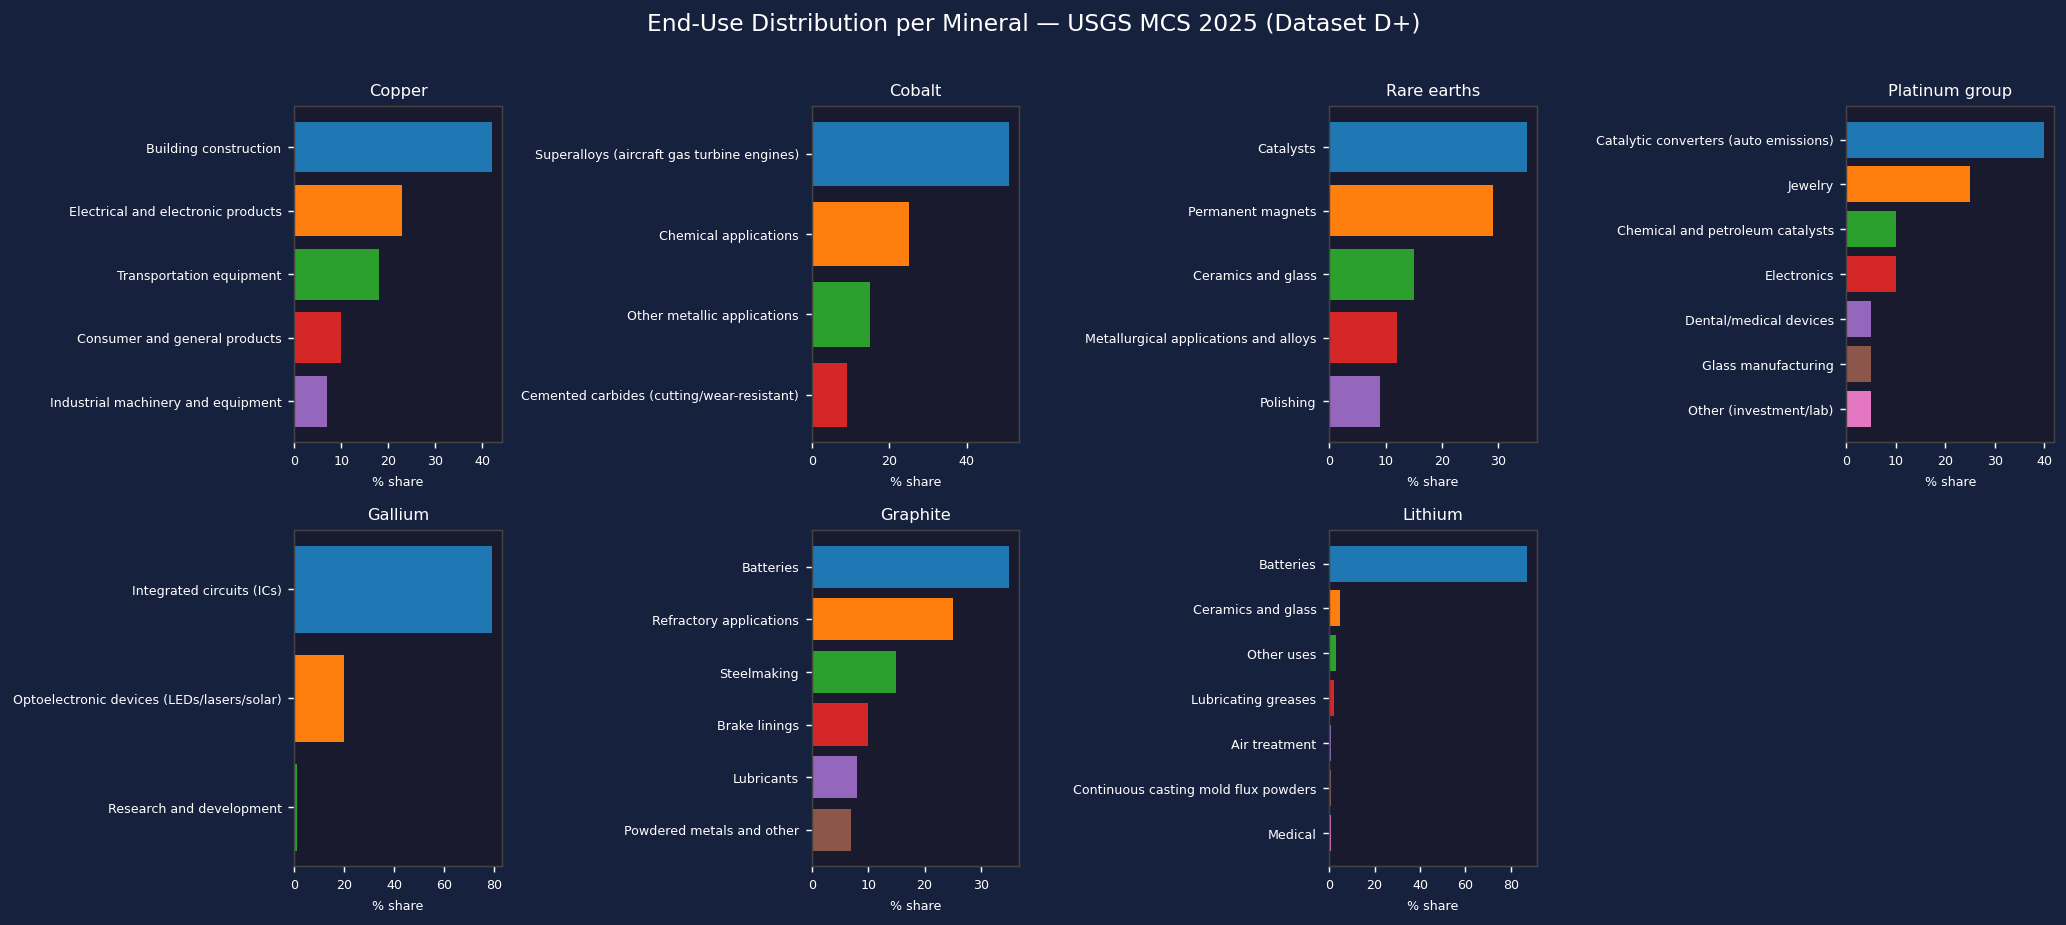

In [ ]:
minerals_eu = df_eu['mineral'].unique()
n = len(minerals_eu)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

cmap = plt.cm.get_cmap('tab10')

for i, mineral in enumerate(minerals_eu):
    df_m = df_eu[df_eu['mineral'] == mineral].sort_values('share_pct', ascending=False)
    colors = [cmap(j) for j in range(len(df_m))]
    axes[i].barh(df_m['end_use'][::-1], df_m['share_pct'][::-1], color=colors[::-1])
    axes[i].set_title(mineral, fontsize=9)
    axes[i].set_xlabel('% share', fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('End-Use Distribution per Mineral — USGS MCS 2025 (Dataset D+)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3f. China's Mining vs Processing Gap (Dataset E)
The key structural insight: China's processing share far exceeds its mining share.

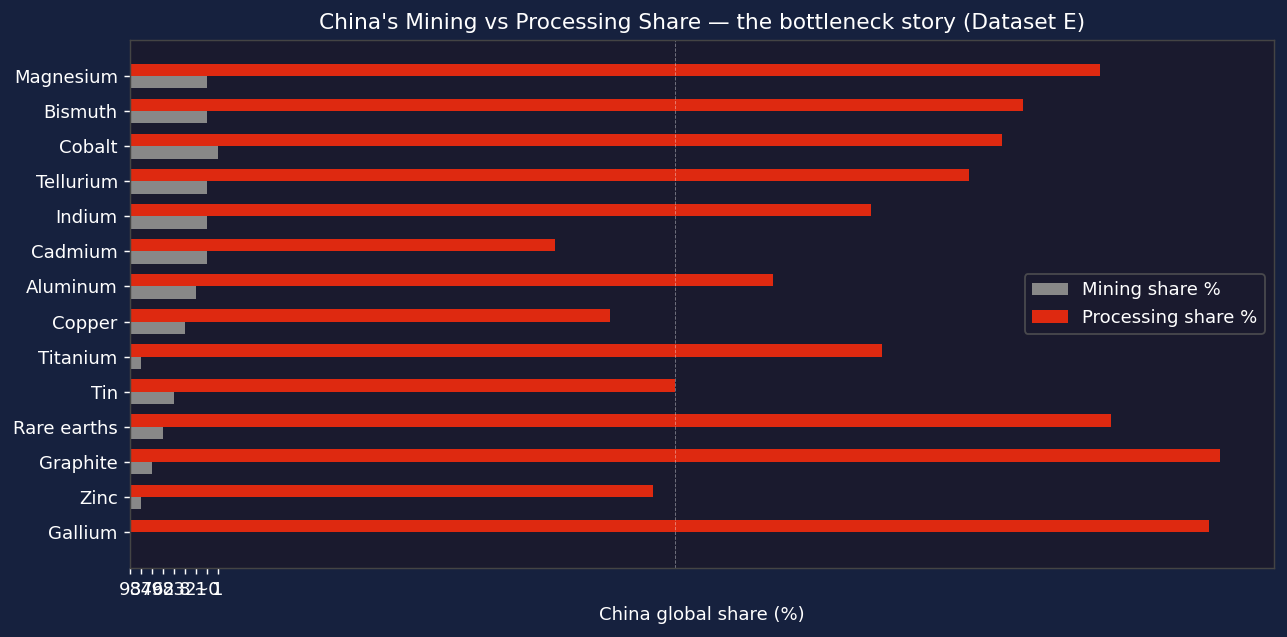


China processing > mining gap (percentage points):
    mineral china_mining_pct china_processing_pct  gap_pp
  Magnesium               ~0                   89    89.0
    Bismuth               ~0                   82    82.0
     Cobalt                1                   80    79.0
  Tellurium               ~0                   77    77.0
     Indium               ~0                   68    68.0
    Cadmium               ~0                   39    39.0
   Aluminum               21                   59    38.0
     Copper                8                   44    36.0
   Titanium               34                   69    35.0
        Tin               23                   50    27.0
Rare earths               68                   90    22.0
   Graphite               79                 ~100    21.0
       Zinc               34                   48    14.0
    Gallium               98                   99     1.0


In [ ]:
# china_mining_vs_processing_summary — the core bifurcation story
df_ch = df_china.copy()
df_ch['gap_pp'] = df_ch['gap_pp'].astype(str).str.replace('+','').astype(float)
df_ch = df_ch.sort_values('gap_pp', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_ch))
w = 0.35

ax.barh([i - w/2 for i in x], df_ch['china_mining_pct'], height=w,
        color='#888888', label='Mining share %')
ax.barh([i + w/2 for i in x], df_ch['china_processing_pct'].replace('~100', '100').astype(float),
        height=w, color=COLORS['China'], label='Processing share %')

ax.set_yticks(list(x))
ax.set_yticklabels(df_ch['mineral'])
ax.axvline(50, color='white', linewidth=0.5, linestyle='--', alpha=0.4)
ax.set_xlabel('China global share (%)')
ax.set_title("China's Mining vs Processing Share — the bottleneck story (Dataset E)", fontsize=12)
ax.legend(facecolor='#1a1a2e', edgecolor='#555')
plt.tight_layout()
plt.show()

print('\nChina processing > mining gap (percentage points):')
print(df_ch[['mineral','china_mining_pct','china_processing_pct','gap_pp']].sort_values('gap_pp', ascending=False).to_string(index=False))

### 3g. Price Distributions — MCS 2025 Snapshot (Dataset D+)

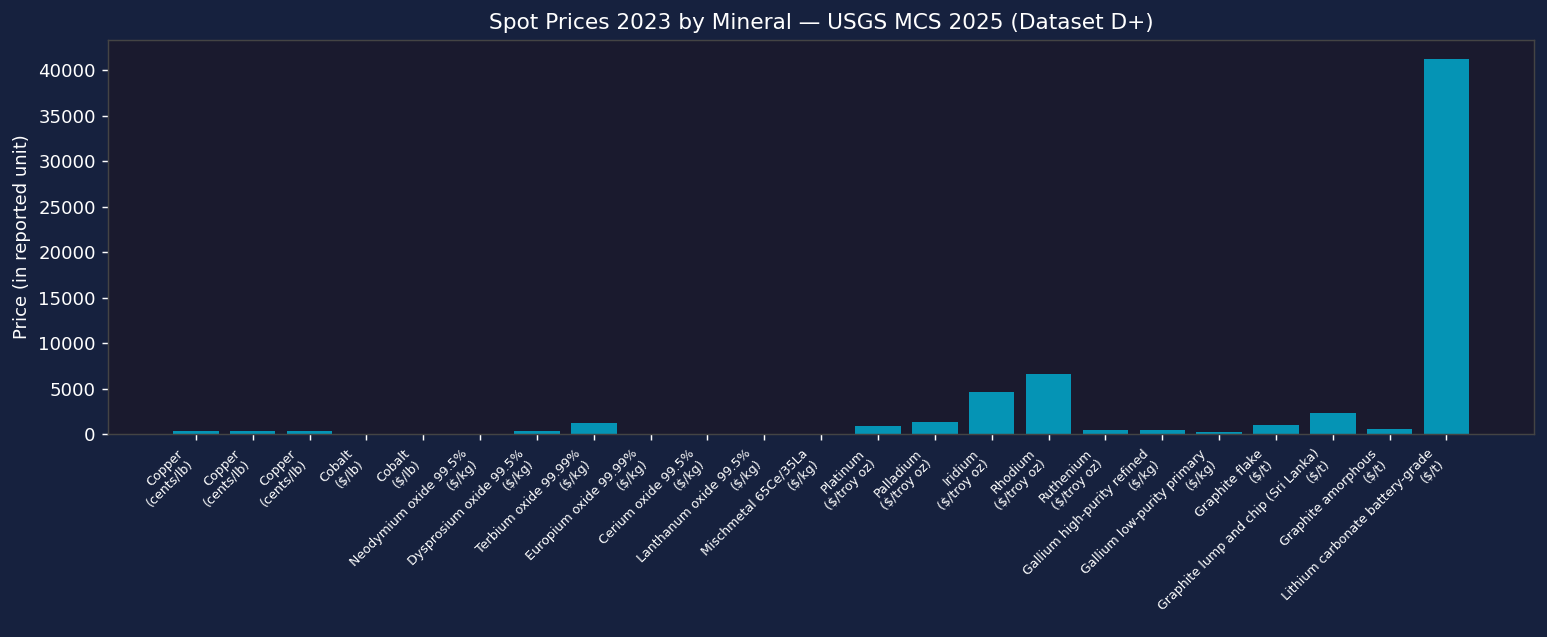

Price range summary:
                           mineral      unit     2023
                            Copper  cents/lb   385.70
                            Copper  cents/lb   384.80
                            Copper  cents/lb   395.30
                            Cobalt      $/lb    17.20
                            Cobalt      $/lb    15.48
             Neodymium oxide 99.5%      $/kg    78.00
            Dysprosium oxide 99.5%      $/kg   330.00
              Terbium oxide 99.99%      $/kg  1298.00
             Europium oxide 99.99%      $/kg    27.00
                Cerium oxide 99.5%      $/kg     1.00
             Lanthanum oxide 99.5%      $/kg     1.00
              Mischmetal 65Ce/35La      $/kg     5.00
                          Platinum $/troy oz   973.00
                         Palladium $/troy oz  1351.66
                           Iridium $/troy oz  4672.78
                           Rhodium $/troy oz  6660.58
                         Ruthenium $/troy oz   466.49
       

In [ ]:
# Use 2023 prices as a cross-section
df_p = df_prices[['mineral','unit','2023']].dropna(subset=['2023']).copy()
df_p['2023'] = pd.to_numeric(df_p['2023'], errors='coerce')
df_p = df_p.dropna()

fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{row['mineral']}\n({row['unit']})" for _, row in df_p.iterrows()]
bars = ax.bar(range(len(df_p)), df_p['2023'], color='#00b4d8', alpha=0.8)
ax.set_xticks(range(len(df_p)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_title('Spot Prices 2023 by Mineral — USGS MCS 2025 (Dataset D+)', fontsize=12)
ax.set_ylabel('Price (in reported unit)')
plt.tight_layout()
plt.show()

print('Price range summary:')
print(df_p[['mineral','unit','2023']].to_string(index=False))

### 3h. USGS Historical Price XLS — Structure Check (Dataset D)

In [ ]:
price_files = {
    'cobalt':      'ds140-cobalt-2021.xlsx',
    'copper':      'ds140-copper-2020.xlsx',
    'gallium':     'ds140-gallium-2021.xlsx',
    'graphite':    'ds140-graphite-2022.xlsx',
    'lithium':     'ds140-lithium-2021.xlsx',
    'platinum':    'ds140-platinum-2022.xlsx',
    'rare earths': 'ds140-rare-earths-2020.xlsx',
}

print(f"{'Mineral':<15} {'Rows':>5} {'Cols':>5}  Columns")
print('-' * 80)
for mineral, fname in price_files.items():
    df_x = pd.read_excel(RAW / 'D USGS Historical Prices' / fname)
    print(f"{mineral:<15} {df_x.shape[0]:>5} {df_x.shape[1]:>5}  {list(df_x.columns)}")

---
## 4. Summary for Presentation

**Total data size:** ~15 MB total — ~4 MB tabular data + ~11 MB PDFs (Dataset E)

**Total records:** ~10,000+ rows across 8 datasets

**Key properties:**
- **Geo:** Dataset A (2,121 deposit points, global), Dataset B (3,114 REE points), Dataset G (177 country polygons)
- **Temporal:** Dataset C spans 1900–2024 (124 years); Dataset D spans ~1900–2021/2022 depending on mineral
- **Cross-sectional:** Datasets D+, E are 2023/2024 snapshots — no time dimension
- **Missing:** Dataset F (Comtrade trade flows) — not yet fetched via API

**Key findings from distributions:**
- Mineral deposits are globally distributed — geology is NOT the bottleneck
- China's processing share exceeds its mining share by 22–79 percentage points depending on mineral
- Cobalt is the extreme case: China mines 1% but processes 80%
- Production of all 8 minerals shows strong upward trend from ~2000 onward (energy transition demand)
- Price data uses heterogeneous units per mineral — normalization to index (base 2015=100) is required